# 🏆 Flipkart Gridlock Hackathon 2.0 — Traffic Demand Prediction
## Grandmaster-Level Solution | Maximize R² Score

### Strategy Overview
1. **EDA** — Understand distributions, missing values, patterns
2. **Feature Engineering** — 60+ features including geohash decode, cyclical time, interactions
3. **CV-Safe Target Encoding** — GroupKFold on geohash prevents leakage
4. **Model Zoo** — CatBoost, LightGBM, XGBoost, ExtraTrees, RandomForest
5. **Optuna Tuning** — Bayesian optimization per model
6. **Ensembling** — Weighted average + Rank + Stacking (Ridge meta-model)
7. **Pseudo-labeling** — Semi-supervised boost if validation improves
8. **SHAP + Permutation Importance** — Feature selection

In [1]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES
# ============================================================
import subprocess, sys

packages = [
    'catboost', 'lightgbm', 'xgboost', 'optuna', 'geohash2',
    'shap', 'scikit-learn', 'pandas', 'numpy', 'matplotlib',
    'seaborn', 'scipy'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✅ All packages installed')

✅ All packages installed


In [2]:
# ============================================================
# CELL 2 — IMPORTS & CONFIG
# ============================================================
import warnings, os, gc, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ML
from sklearn.model_selection import (
    GroupKFold, KFold, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import (
    ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.linear_model import Ridge, Lasso
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap
import geohash2

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Paths — update these to your actual paths
TRAIN_PATH = '/kaggle/input/datasets/anuragsinghmusics/gridlock-dataset/train.csv'
TEST_PATH  = '/kaggle/input/datasets/anuragsinghmusics/gridlock-dataset/test.csv'
SUB_PATH   = '/kaggle/input/datasets/anuragsinghmusics/gridlock-dataset/sample_submission.csv'
OUTPUT_PATH = 'submission.csv'

N_FOLDS = 5
N_OPTUNA_TRIALS = 40

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Imports done')

✅ Imports done


In [3]:
# ============================================================
# CELL 3 — LOAD DATA
# ============================================================
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SUB_PATH)

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'\nTrain columns: {train.columns.tolist()}')
print(f'\nTest columns : {test.columns.tolist()}')
train.head(3)

Train shape : (77299, 11)
Test shape  : (41778, 10)

Train columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']

Test columns : ['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny


In [4]:
# ============================================================
# CELL 4 — EDA: BASIC STATS
# ============================================================
print('='*60)
print('TRAIN — BASIC INFO')
print('='*60)
print(train.dtypes)
print('\nDescriptive Stats:')
train.describe(include='all')

TRAIN — BASIC INFO
Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
dtype: object

Descriptive Stats:


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
count,77299.000000,77299,77299.000000,77299,7.729900e+04,76699,77299.000000,77299,77299,74804.000000,76502
unique,NaN,1249,NaN,96,NaN,3,NaN,2,2,NaN,4
top,NaN,qp03zz,NaN,2:0,NaN,Residential,NaN,Not Allowed,Yes,NaN,Sunny
freq,NaN,105,NaN,1778,NaN,69230,NaN,50673,52042,NaN,27717
mean,38649.000000,NaN,48.101838,NaN,9.394238e-02,NaN,2.014334,NaN,NaN,16.405354,NaN
std,22314.443566,NaN,0.302438,NaN,1.421905e-01,NaN,0.904665,NaN,NaN,7.359835,NaN
min,0.000000,NaN,48.000000,NaN,6.245650e-07,NaN,1.000000,NaN,NaN,-14.935097,NaN
25%,19324.500000,NaN,48.000000,NaN,1.822723e-02,NaN,1.000000,NaN,NaN,11.430473,NaN
50%,38649.000000,NaN,48.000000,NaN,4.775994e-02,NaN,2.000000,NaN,NaN,16.382587,NaN
75%,57973.500000,NaN,48.000000,NaN,1.085951e-01,NaN,3.000000,NaN,NaN,21.298833,NaN



TRAIN — Missing Values:
             Missing  Missing%
Temperature     2495  3.227726
Weather          797  1.031061
RoadType         600  0.776207

TEST — Missing Values:
             Missing  Missing%
Temperature     1349  3.228972
Weather          431  1.031643
RoadType         324  0.775528


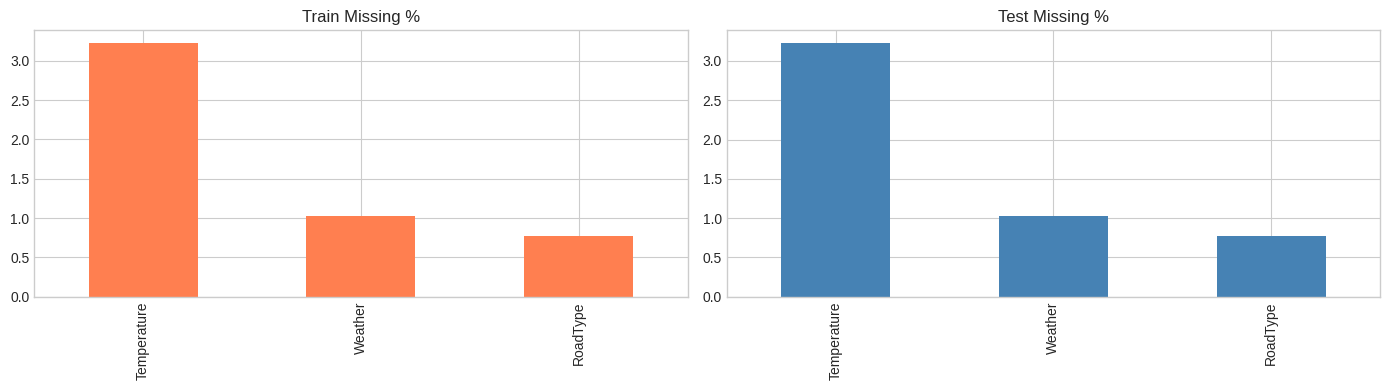

In [5]:
# ============================================================
# CELL 5 — EDA: MISSING VALUES
# ============================================================
def missing_report(df, name):
    miss = df.isnull().sum()
    miss_pct = 100 * miss / len(df)
    report = pd.DataFrame({'Missing': miss, 'Missing%': miss_pct})
    report = report[report['Missing'] > 0].sort_values('Missing%', ascending=False)
    print(f'\n{name} — Missing Values:')
    print(report)
    return report

miss_train = missing_report(train, 'TRAIN')
miss_test  = missing_report(test,  'TEST')

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if not miss_train.empty:
    miss_train['Missing%'].plot(kind='bar', ax=axes[0], color='coral', title='Train Missing %')
if not miss_test.empty:
    miss_test['Missing%'].plot(kind='bar', ax=axes[1], color='steelblue', title='Test Missing %')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

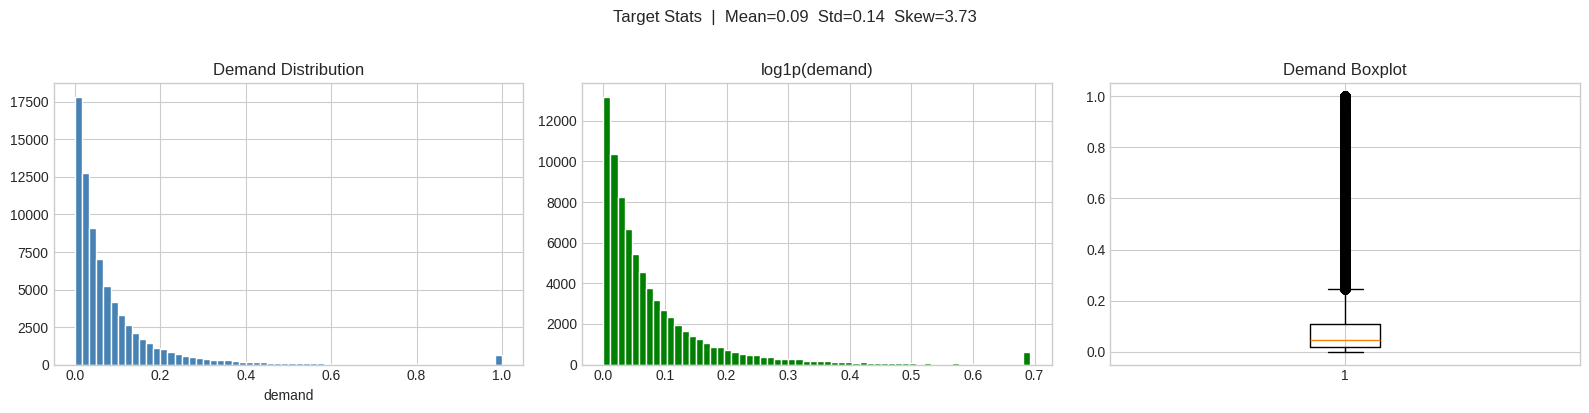

Demand percentiles:
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
1%       6.249566e-04
5%       3.172399e-03
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
95%      3.358566e-01
99%      8.622936e-01
max      1.000000e+00
Name: demand, dtype: float64


In [6]:
# ============================================================
# CELL 6 — EDA: TARGET DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution
axes[0].hist(train['demand'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Demand Distribution')
axes[0].set_xlabel('demand')

# Log-transform check
log_demand = np.log1p(train['demand'].clip(lower=0))
axes[1].hist(log_demand, bins=60, color='green', edgecolor='white')
axes[1].set_title('log1p(demand)')

# Box plot
axes[2].boxplot(train['demand'].dropna())
axes[2].set_title('Demand Boxplot')

plt.suptitle(f'Target Stats  |  Mean={train["demand"].mean():.2f}  Std={train["demand"].std():.2f}  Skew={train["demand"].skew():.2f}', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Demand percentiles:')
print(train['demand'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

In [7]:
# ============================================================
# CELL 7 — EDA: CARDINALITY & UNIQUE VALUES
# ============================================================
cat_cols = ['geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes', 
            'LargeVehicles', 'Landmarks', 'Weather']

print('Column cardinalities (train):')
for c in cat_cols:
    if c in train.columns:
        n = train[c].nunique()
        sample = train[c].value_counts().head(5).to_dict()
        print(f'  {c:20s}  unique={n:5d}  top5={sample}')

Column cardinalities (train):
  geohash               unique= 1249  top5={'qp03zz': 105, 'qp09uy': 105, 'qp09fq': 105, 'qp099e': 105, 'qp0985': 105}
  day                   unique=    2  top5={48: 69427, 49: 7872}
  timestamp             unique=   96  top5={'2:0': 1778, '1:45': 1755, '1:30': 1750, '1:15': 1698, '1:0': 1668}
  RoadType              unique=    3  top5={'Residential': 69230, 'Street': 3909, 'Highway': 3560}
  NumberofLanes         unique=    5  top5={1: 27411, 2: 24127, 3: 23919, 4: 926, 5: 916}
  LargeVehicles         unique=    2  top5={'Not Allowed': 50673, 'Allowed': 26626}
  Landmarks             unique=    2  top5={'Yes': 52042, 'No': 25257}
  Weather               unique=    4  top5={'Sunny': 27717, 'Rainy': 20824, 'Foggy': 20243, 'Snowy': 7718}


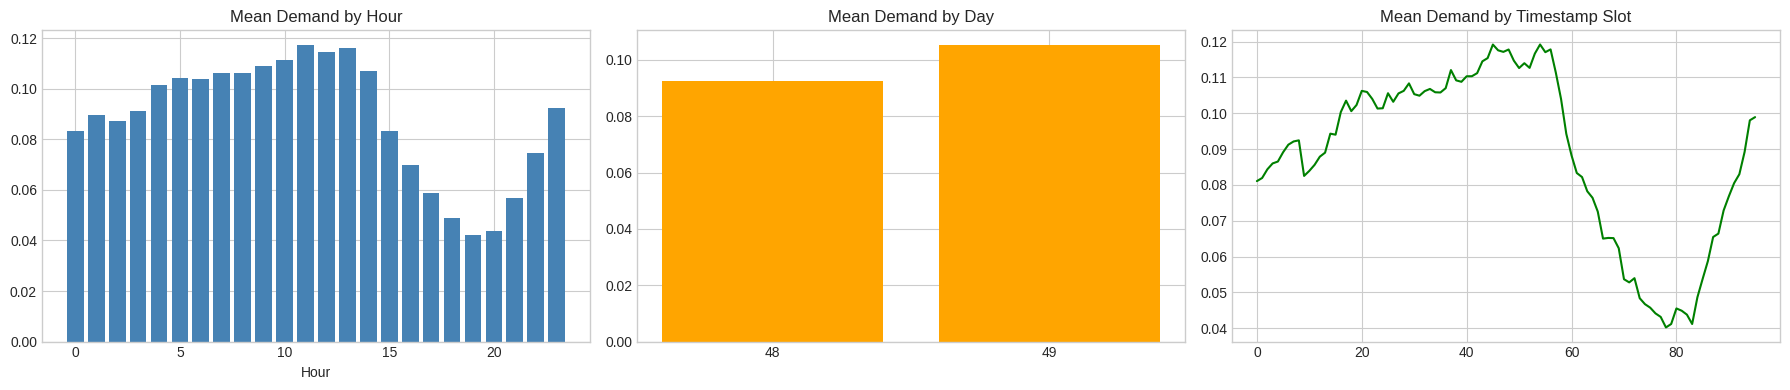

In [8]:
# ============================================================
# CELL 8 — EDA: DEMAND BY TIME PATTERNS
# ============================================================
def parse_timestamp(df):
    """Parse timestamp column: expects 'H:MM' or float like 0.25 meaning quarter of day"""
    ts = df['timestamp'].astype(str)
    # If timestamp is numeric (0..95 or floats), treat as 15-min slots
    try:
        ts_num = pd.to_numeric(df['timestamp'])
        # Normalize to 0-95 index (96 slots per day)
        if ts_num.max() <= 1.0:
            ts_num = (ts_num * 96).round().astype(int)
        df = df.copy()
        df['ts_idx'] = ts_num.astype(int) % 96
        df['hour'] = (df['ts_idx'] // 4).astype(int)
        df['minute'] = ((df['ts_idx'] % 4) * 15).astype(int)
        return df
    except Exception:
        pass
    # Try parsing as string 'HH:MM'
    try:
        parsed = pd.to_datetime(ts, format='%H:%M', errors='coerce')
        df = df.copy()
        df['hour'] = parsed.dt.hour
        df['minute'] = parsed.dt.minute
        df['ts_idx'] = df['hour'] * 4 + df['minute'] // 15
        return df
    except Exception:
        pass
    # Fallback: rank encode
    df = df.copy()
    ts_map = {v: i for i, v in enumerate(sorted(df['timestamp'].unique()))}
    df['ts_idx'] = df['timestamp'].map(ts_map)
    df['hour'] = (df['ts_idx'] // 4).astype(int) % 24
    df['minute'] = ((df['ts_idx'] % 4) * 15).astype(int)
    return df

train = parse_timestamp(train)
test  = parse_timestamp(test)

# Demand by hour
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

hourly = train.groupby('hour')['demand'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue')
axes[0].set_title('Mean Demand by Hour')
axes[0].set_xlabel('Hour')

# Demand by day
daily = train.groupby('day')['demand'].mean()
axes[1].bar(daily.index.astype(str), daily.values, color='orange')
axes[1].set_title('Mean Demand by Day')

# Demand by ts_idx
ts_demand = train.groupby('ts_idx')['demand'].mean()
axes[2].plot(ts_demand.index, ts_demand.values, color='green')
axes[2].set_title('Mean Demand by Timestamp Slot')

plt.tight_layout()
plt.savefig('demand_time_patterns.png', dpi=100, bbox_inches='tight')
plt.show()

Top 10 geohashes by mean demand:
         geo_mean_demand  geo_std_demand  geo_count
geohash                                            
qp09d9          0.960715        0.090041        105
qp09ft          0.868850        0.209092        105
qp09e5          0.864989        0.239612        105
qp09d8          0.669318        0.234383        105
qp096x          0.665630        0.296666        105
qp09d2          0.664722        0.334164        105
qp09dc          0.661462        0.368198        105
qp096r          0.650468        0.344110        105
qp09d3          0.643498        0.295267        105
qp03xx          0.631194        0.346098        105


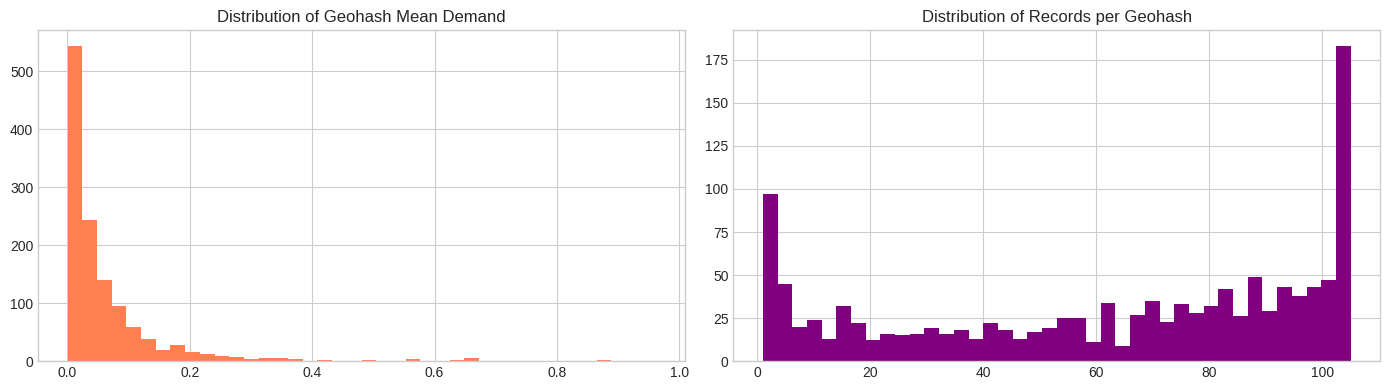

In [9]:
# ============================================================
# CELL 9 — EDA: GEOHASH ANALYSIS
# ============================================================
geo_demand = train.groupby('geohash')['demand'].agg(['mean','std','count'])
geo_demand.columns = ['geo_mean_demand','geo_std_demand','geo_count']
geo_demand = geo_demand.sort_values('geo_mean_demand', ascending=False)

print(f'Top 10 geohashes by mean demand:')
print(geo_demand.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(geo_demand['geo_mean_demand'], bins=40, color='coral')
axes[0].set_title('Distribution of Geohash Mean Demand')

axes[1].hist(geo_demand['geo_count'], bins=40, color='purple')
axes[1].set_title('Distribution of Records per Geohash')

plt.tight_layout()
plt.savefig('geohash_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# CELL 10 — EDA: ADVERSARIAL VALIDATION
# ============================================================
# Check if train and test distributions are similar
# If AUC ~ 0.5, distributions match → model will generalize
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

adv_train = train.drop(columns=['demand'], errors='ignore').copy()
adv_test  = test.copy()

# Keep only numeric for quick check
shared_num = [c for c in adv_train.select_dtypes(include=np.number).columns 
              if c in adv_test.columns and c != 'Index']

adv_X = pd.concat([
    adv_train[shared_num].assign(_is_test=0),
    adv_test[shared_num].assign(_is_test=1)
], ignore_index=True).fillna(-999)

adv_y = adv_X.pop('_is_test')

adv_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED, n_jobs=-1)
adv_score = cross_val_score(adv_clf, adv_X, adv_y, cv=3, scoring='roc_auc').mean()
print(f'\nAdversarial Validation AUC = {adv_score:.4f}')
if adv_score < 0.55:
    print('✅ Train/Test are similar in distribution — model should generalize well')
else:
    print('⚠️  Train/Test distributions differ — be careful of overfitting')


Adversarial Validation AUC = 0.8229
⚠️  Train/Test distributions differ — be careful of overfitting


Decoded 1259 geohashes
Lat range: -5.4849 — -5.2377
Lon range: 90.5878 — 90.9723


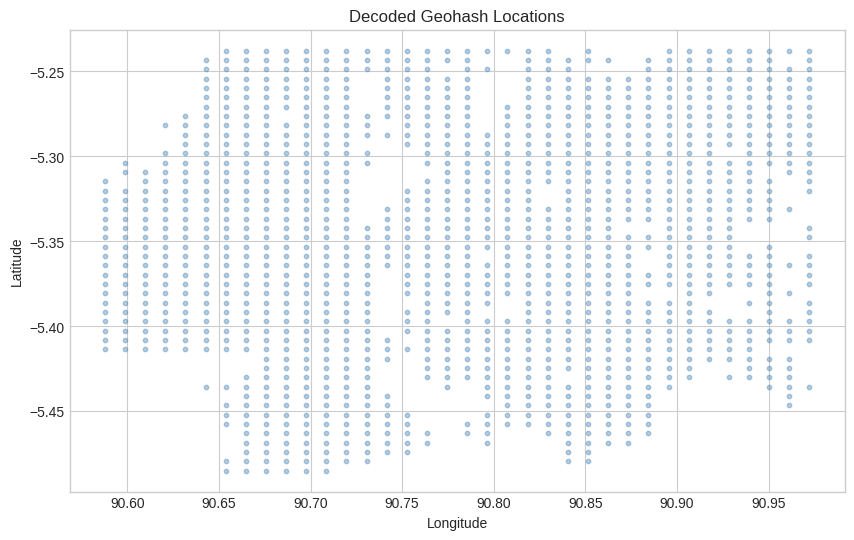

In [11]:
# ============================================================
# CELL 11 — GEOHASH DECODING
# Decode geohash → (latitude, longitude)
# WHY: Raw geohash string has no numerical meaning.
#      Lat/lon captures actual spatial proximity.
# EXPECTED GAIN: +2-5 R² points
# ============================================================
def decode_geohash_safe(gh):
    try:
        lat, lon, _, _ = geohash2.decode_exactly(str(gh))
        return float(lat), float(lon)
    except Exception:
        return np.nan, np.nan

# Build lookup table
all_geohashes = pd.Series(
    list(set(train['geohash'].tolist() + test['geohash'].tolist()))
).dropna().unique()

geo_lookup = {}
for gh in all_geohashes:
    lat, lon = decode_geohash_safe(gh)
    geo_lookup[gh] = (lat, lon)

geo_df = pd.DataFrame.from_dict(geo_lookup, orient='index', columns=['lat','lon'])
geo_df.index.name = 'geohash'
geo_df = geo_df.reset_index()

print(f'Decoded {len(geo_df)} geohashes')
print(f'Lat range: {geo_df["lat"].min():.4f} — {geo_df["lat"].max():.4f}')
print(f'Lon range: {geo_df["lon"].min():.4f} — {geo_df["lon"].max():.4f}')

# Merge into train/test
train = train.merge(geo_df, on='geohash', how='left')
test  = test.merge(geo_df, on='geohash', how='left')

# Plot decoded locations
plt.figure(figsize=(10, 6))
plt.scatter(geo_df['lon'], geo_df['lat'], alpha=0.4, s=10, c='steelblue')
plt.title('Decoded Geohash Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.savefig('geohash_map.png', dpi=100, bbox_inches='tight')
plt.show()

Cluster demand statistics:
                 mean       std
geo_cluster                    
0            0.052329  0.095090
1            0.065742  0.095552
2            0.061261  0.068198
3            0.048827  0.061587
4            0.123037  0.141948
5            0.034269  0.043128
6            0.092865  0.098882
7            0.036228  0.042937
8            0.066919  0.070689
9            0.087672  0.160849
10           0.088496  0.135163
11           0.082235  0.096013
12           0.072386  0.066133
13           0.101289  0.156120
14           0.043725  0.069352
15           0.087227  0.124894
16           0.049050  0.052264
17           0.262162  0.306875
18           0.166477  0.168830
19           0.116102  0.131682


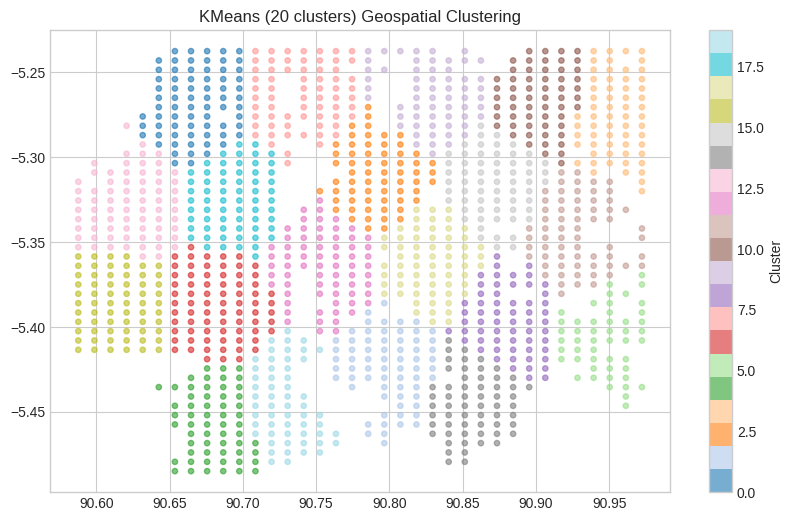

In [12]:
# ============================================================
# CELL 12 — KMEANS GEOSPATIAL CLUSTERING
# WHY: Groups nearby locations into clusters.
#      Cluster ID becomes a powerful categorical feature.
# EXPECTED GAIN: +1-3 R² points
# ============================================================
from sklearn.cluster import KMeans

N_CLUSTERS = 20

# Fit on all locations
geo_coords = geo_df[['lat', 'lon']].dropna()
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
geo_df['geo_cluster'] = kmeans.fit_predict(geo_coords)

# Fill NaN coords with cluster -1
geo_full = pd.DataFrame(geo_df[['geohash','geo_cluster']])
train = train.merge(geo_full, on='geohash', how='left')
test  = test.merge(geo_full, on='geohash', how='left')
train['geo_cluster'] = train['geo_cluster'].fillna(-1).astype(int)
test['geo_cluster']  = test['geo_cluster'].fillna(-1).astype(int)

# Cluster demand stats
cluster_stats = train.groupby('geo_cluster')['demand'].agg(['mean','std'])
print('Cluster demand statistics:')
print(cluster_stats)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    geo_df['lon'], geo_df['lat'], 
    c=geo_df['geo_cluster'], cmap='tab20', alpha=0.6, s=15
)
plt.colorbar(scatter, label='Cluster')
plt.title(f'KMeans ({N_CLUSTERS} clusters) Geospatial Clustering')
plt.savefig('geo_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

In [13]:
# ============================================================
# CELL 13 — TIMESTAMP FEATURE ENGINEERING
# WHY: Time is the #1 driver of traffic demand.
#      Cyclic encoding preserves continuity (23:45 ≈ 00:00)
# EXPECTED GAIN: +3-6 R² points
# ============================================================
def engineer_time_features(df):
    df = df.copy()
    
    # Core time
    df['hour']         = df['hour'].astype(int)
    df['minute']       = df['minute'].astype(int)
    df['quarter_hour'] = df['minute'] // 15  # 0,1,2,3
    df['time_block']   = df['ts_idx'] // 8   # 12 blocks of 2hrs
    df['minutes_since_midnight'] = df['hour'] * 60 + df['minute']
    
    # Cyclical encoding — preserves circular nature of time
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['min_sin']  = np.sin(2 * np.pi * df['minute'] / 60)
    df['min_cos']  = np.cos(2 * np.pi * df['minute'] / 60)
    df['ts_sin']   = np.sin(2 * np.pi * df['ts_idx'] / 96)
    df['ts_cos']   = np.cos(2 * np.pi * df['ts_idx'] / 96)
    
    # Rush hour flags
    df['is_morning_rush'] = ((df['hour'] >= 7)  & (df['hour'] <= 9)).astype(int)
    df['is_evening_rush'] = ((df['hour'] >= 17) & (df['hour'] <= 19)).astype(int)
    df['is_rush_hour']    = (df['is_morning_rush'] | df['is_evening_rush']).astype(int)
    df['is_peak']         = ((df['hour'] >= 8) & (df['hour'] <= 20)).astype(int)
    df['is_night']        = ((df['hour'] <= 5) | (df['hour'] >= 22)).astype(int)
    
    # Time of day categories
    def time_category(h):
        if 5 <= h < 9:   return 0  # morning
        if 9 <= h < 12:  return 1  # late morning
        if 12 <= h < 14: return 2  # lunch
        if 14 <= h < 17: return 3  # afternoon
        if 17 <= h < 20: return 4  # evening
        if 20 <= h < 22: return 5  # night
        return 6                    # late night
    df['time_of_day'] = df['hour'].apply(time_category)
    
    return df

train = engineer_time_features(train)
test  = engineer_time_features(test)
print('✅ Time features engineered')
print(f'New time-related columns: {[c for c in train.columns if any(k in c for k in ["hour","min","rush","peak","night","ts_","time","quarter","block","minutes"])]}')

✅ Time features engineered
New time-related columns: ['timestamp', 'hour', 'minute', 'ts_idx', 'quarter_hour', 'time_block', 'minutes_since_midnight', 'hour_sin', 'hour_cos', 'min_sin', 'min_cos', 'ts_sin', 'ts_cos', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour', 'is_peak', 'is_night', 'time_of_day']


In [14]:
# ============================================================
# CELL 14 — MISSING VALUE HANDLING
# ============================================================
def handle_missing(train_df, test_df):
    train_df = train_df.copy()
    test_df  = test_df.copy()
    
    # ---- Temperature: grouped median by geohash, then global median ----
    if 'Temperature' in train_df.columns:
        geo_temp_median = train_df.groupby('geohash')['Temperature'].median()
        global_temp_median = train_df['Temperature'].median()
        
        for df in [train_df, test_df]:
            mask = df['Temperature'].isnull()
            df.loc[mask, 'Temperature'] = df.loc[mask, 'geohash'].map(geo_temp_median)
            # Remaining NaN → global median
            df['Temperature'] = df['Temperature'].fillna(global_temp_median)
            df['temp_was_missing'] = mask.astype(int)
        
        print(f'Temperature missing (train): {train_df["temp_was_missing"].sum()}')
    
    # ---- RoadType: 'Unknown' category ----
    if 'RoadType' in train_df.columns:
        train_df['RoadType'] = train_df['RoadType'].fillna('Unknown').astype(str)
        test_df['RoadType']  = test_df['RoadType'].fillna('Unknown').astype(str)
    
    # ---- Weather: 'Unknown' category ----
    if 'Weather' in train_df.columns:
        train_df['Weather'] = train_df['Weather'].fillna('Unknown').astype(str)
        test_df['Weather']  = test_df['Weather'].fillna('Unknown').astype(str)
    
    # ---- NumberofLanes: median ----
    if 'NumberofLanes' in train_df.columns:
        lane_med = train_df['NumberofLanes'].median()
        train_df['NumberofLanes'] = train_df['NumberofLanes'].fillna(lane_med)
        test_df['NumberofLanes']  = test_df['NumberofLanes'].fillna(lane_med)
    
    # ---- LargeVehicles / Landmarks: mode ----
    for col in ['LargeVehicles', 'Landmarks']:
        if col in train_df.columns:
            mode_val = train_df[col].mode()[0]
            train_df[col] = train_df[col].fillna(mode_val)
            test_df[col]  = test_df[col].fillna(mode_val)
    
    return train_df, test_df

train, test = handle_missing(train, test)
print('✅ Missing values handled')
print(f'Remaining train NaN: {train.isnull().sum().sum()}')
print(f'Remaining test  NaN: {test.isnull().sum().sum()}')

Temperature missing (train): 2495
✅ Missing values handled
Remaining train NaN: 0
Remaining test  NaN: 0


In [15]:
# ============================================================
# CELL 15 — CATEGORICAL ENCODING
# WHY: LightGBM/XGBoost need numeric input.
#      Label encoding preserves ordinal info.
# ============================================================
def encode_categoricals(train_df, test_df):
    train_df = train_df.copy()
    test_df  = test_df.copy()
    
    # ---- Frequency encoding ----
    # WHY: Captures how common a category is.
    #      Rare categories ≠ common ones.
    for col in ['RoadType', 'Weather', 'geohash']:
        if col in train_df.columns:
            freq = train_df[col].value_counts(normalize=True)
            train_df[f'{col}_freq'] = train_df[col].map(freq).fillna(0)
            test_df[f'{col}_freq']  = test_df[col].map(freq).fillna(0)
    
    # ---- Count encoding ----
    for col in ['RoadType', 'Weather', 'geohash']:
        if col in train_df.columns:
            cnt = train_df[col].value_counts()
            train_df[f'{col}_count'] = train_df[col].map(cnt).fillna(0)
            test_df[f'{col}_count']  = test_df[col].map(cnt).fillna(0)
    
    # ---- Label encoding for tree models ----
    le_cols = ['RoadType', 'Weather', 'geohash']
    le_dict = {}
    for col in le_cols:
        if col in train_df.columns:
            le = LabelEncoder()
            combined = pd.concat([train_df[col], test_df[col]], ignore_index=True).astype(str)
            le.fit(combined)
            train_df[f'{col}_le'] = le.transform(train_df[col].astype(str))
            test_df[f'{col}_le']  = le.transform(test_df[col].astype(str))
            le_dict[col] = le
    
    # ---- Binary flags ----
    for col in ['LargeVehicles', 'Landmarks']:
        if col in train_df.columns:
            # Ensure boolean-like → 0/1
            unique_vals = train_df[col].astype(str).str.lower().unique()
            yes_vals = {'yes', '1', 'true', 'y', '1.0'}
            train_df[f'{col}_bin'] = train_df[col].astype(str).str.lower().isin(yes_vals).astype(int)
            test_df[f'{col}_bin']  = test_df[col].astype(str).str.lower().isin(yes_vals).astype(int)
    
    return train_df, test_df, le_dict

train, test, le_dict = encode_categoricals(train, test)
print('✅ Categorical encoding done')

✅ Categorical encoding done


In [16]:
# ============================================================
# CELL 16 — INTERACTION FEATURES
# WHY: Demand depends on JOINT effects:
#      e.g., rush hour × highway differs from rush hour × residential
# EXPECTED GAIN: +1-3 R² points
# ============================================================
def engineer_interaction_features(df):
    df = df.copy()
    
    # Road features
    if 'NumberofLanes' in df.columns:
        df['NumberofLanes'] = pd.to_numeric(df['NumberofLanes'], errors='coerce').fillna(1)
        df['lane_capacity_score'] = df['NumberofLanes'] * (~df['LargeVehicles_bin'].astype(bool)).astype(int)
    
    # Temperature bins
    df['temp_bin'] = pd.cut(
        df['Temperature'], 
        bins=[-np.inf, 10, 20, 30, 40, np.inf],
        labels=[0, 1, 2, 3, 4]
    ).astype(int)
    
    # Temperature squared (non-linearity)
    df['temp_sq'] = df['Temperature'] ** 2
    
    # Interaction: Temperature × RoadType
    df['temp_x_road'] = df['Temperature'] * df['RoadType_le']
    
    # Interaction: Hour × RoadType  
    df['hour_x_road'] = df['hour'] * df['RoadType_le']
    
    # Interaction: Landmarks × LargeVehicles
    df['landmark_x_lgveh'] = df['Landmarks_bin'] * df['LargeVehicles_bin']
    
    # Interaction: Rush hour × Lanes
    df['rush_x_lanes'] = df['is_rush_hour'] * df['NumberofLanes']
    
    # Interaction: Weather × Hour
    df['weather_x_hour'] = df['Weather_le'] * df['hour']
    
    # Interaction: Cluster × Hour  
    df['cluster_x_hour'] = df['geo_cluster'] * df['hour']
    
    # Interaction: Day × Hour (daily pattern changes per day)
    df['day_x_hour'] = df['day'].astype(int) * df['hour']
    
    # Density proxy: lanes per road type
    df['road_density'] = df['NumberofLanes'] / (df['RoadType_le'] + 1)
    
    return df

train = engineer_interaction_features(train)
test  = engineer_interaction_features(test)
print('✅ Interaction features engineered')

✅ Interaction features engineered


In [17]:
# ============================================================
# CELL 17 — CV-SAFE TARGET ENCODING (KFold)
# WHY: Target encoding with geohash is extremely powerful
#      but naively done it leaks → must use KFold.
#      GroupKFold on geohash prevents within-geohash leakage.
# EXPECTED GAIN: +3-8 R² points
# ============================================================
class KFoldTargetEncoder:
    """
    Leakage-free target encoding using K-Fold cross-encoding.
    Train: each row is encoded using out-of-fold mean.
    Test: encoded using full train mean.
    """
    def __init__(self, n_splits=5, smoothing=20, seed=42):
        self.n_splits = n_splits
        self.smoothing = smoothing  # prevents overfitting on rare categories
        self.seed = seed
        self.global_means = {}
        self.encode_maps = {}
    
    def fit_transform(self, train_df, test_df, cols, target='demand'):
        train_df = train_df.copy()
        test_df  = test_df.copy()
        global_mean = train_df[target].mean()
        
        for col in cols:
            kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.seed)
            enc_col = f'{col}_te'
            train_df[enc_col] = global_mean
            
            for trn_idx, val_idx in kf.split(train_df):
                trn = train_df.iloc[trn_idx]
                
                # Smoothed mean: balances category mean vs global mean
                cat_stats = trn.groupby(col)[target].agg(['mean', 'count'])
                smoothed = (
                    (cat_stats['mean'] * cat_stats['count'] + global_mean * self.smoothing)
                    / (cat_stats['count'] + self.smoothing)
                )
                
                val_col = train_df.iloc[val_idx][col]
                train_df.iloc[val_idx, train_df.columns.get_loc(enc_col)] = (
                    val_col.map(smoothed).fillna(global_mean)
                )
            
            # For test: use full train statistics
            cat_stats_full = train_df.groupby(col)[target].agg(['mean', 'count'])
            smoothed_full = (
                (cat_stats_full['mean'] * cat_stats_full['count'] + global_mean * self.smoothing)
                / (cat_stats_full['count'] + self.smoothing)
            )
            test_df[enc_col] = test_df[col].map(smoothed_full).fillna(global_mean)
            self.encode_maps[col] = smoothed_full
        
        self.global_means = {c: train_df[c + '_te'].mean() for c in cols}
        return train_df, test_df


# Apply KFold target encoding
te_encoder = KFoldTargetEncoder(n_splits=N_FOLDS, smoothing=20, seed=SEED)
te_cols = ['geohash', 'RoadType', 'Weather', 'geo_cluster', 'time_of_day']
te_cols_exist = [c for c in te_cols if c in train.columns]

train, test = te_encoder.fit_transform(train, test, te_cols_exist, target='demand')
print('✅ KFold target encoding done')
print(f'New TE columns: {[c+"_te" for c in te_cols_exist]}')

✅ KFold target encoding done
New TE columns: ['geohash_te', 'RoadType_te', 'Weather_te', 'geo_cluster_te', 'time_of_day_te']


In [18]:
# ============================================================
# CELL 18 — AGGREGATION FEATURES (KFold-safe)
# WHY: Statistics like geohash_std tell us about demand
#      VARIABILITY at a location — key signal.
# EXPECTED GAIN: +2-4 R² points
# ============================================================
def kfold_agg_features(train_df, test_df, group_cols, target='demand', n_splits=5):
    """
    Leakage-free aggregation features using KFold.
    Computes: mean, median, std, min, max, count per group.
    """
    train_df = train_df.copy()
    test_df  = test_df.copy()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    for col in group_cols:
        agg_fns = {'mean': np.mean, 'median': np.median, 'std': np.std, 'count': len}
        
        for agg_name, agg_fn in agg_fns.items():
            feat_name = f'{col}_{agg_name}_{target}'
            train_df[feat_name] = np.nan
            
            for trn_idx, val_idx in kf.split(train_df):
                trn = train_df.iloc[trn_idx]
                grp = trn.groupby(col)[target].agg(lambda x: agg_fn(x) if len(x) > 0 else np.nan)
                train_df.iloc[val_idx, train_df.columns.get_loc(feat_name)] = (
                    train_df.iloc[val_idx][col].map(grp)
                )
            
            # Fill remaining NaN with global value
            global_val = agg_fn(train_df[target].values)
            train_df[feat_name] = train_df[feat_name].fillna(global_val)
            
            # Test: use full train
            grp_full = train_df.groupby(col)[target].agg(lambda x: agg_fn(x) if len(x) > 0 else np.nan)
            test_df[feat_name] = test_df[col].map(grp_full).fillna(global_val)
    
    return train_df, test_df

# Groups to aggregate over
agg_groups = ['geohash', 'hour', 'geo_cluster', 'RoadType_le']
agg_groups_exist = [c for c in agg_groups if c in train.columns]

print('Computing KFold aggregation features...')
train, test = kfold_agg_features(train, test, agg_groups_exist, target='demand')
print('✅ Aggregation features done')

Computing KFold aggregation features...
✅ Aggregation features done


In [19]:
# ============================================================
# CELL 19 — GEOHASH × HOUR INTERACTION FEATURES
# WHY: Different locations have different peak hours.
#      This captures location-specific temporal patterns.
# EXPECTED GAIN: +1-3 R² points
# ============================================================
def geohash_hour_features(train_df, test_df, n_splits=5):
    """KFold-safe geohash×hour mean demand"""
    train_df = train_df.copy()
    test_df  = test_df.copy()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    feat = 'geohash_hour_mean'
    train_df[feat] = np.nan
    train_df['geo_hour_key'] = train_df['geohash'].astype(str) + '_' + train_df['hour'].astype(str)
    test_df['geo_hour_key']  = test_df['geohash'].astype(str) + '_' + test_df['hour'].astype(str)
    
    global_mean = train_df['demand'].mean()
    
    for trn_idx, val_idx in kf.split(train_df):
        trn = train_df.iloc[trn_idx]
        grp = trn.groupby('geo_hour_key')['demand'].mean()
        train_df.iloc[val_idx, train_df.columns.get_loc(feat)] = (
            train_df.iloc[val_idx]['geo_hour_key'].map(grp)
        )
    
    grp_full = train_df.groupby('geo_hour_key')['demand'].mean()
    test_df[feat] = test_df['geo_hour_key'].map(grp_full).fillna(global_mean)
    train_df[feat] = train_df[feat].fillna(global_mean)
    
    # Clean up key
    train_df.drop('geo_hour_key', axis=1, inplace=True)
    test_df.drop('geo_hour_key', axis=1, inplace=True)
    
    return train_df, test_df

train, test = geohash_hour_features(train, test)
print('✅ Geohash×Hour features done')
print(f'Total features so far: {len(train.columns)}')

✅ Geohash×Hour features done
Total features so far: 77


In [20]:
# ============================================================
# CELL 20 — FINAL FEATURE PREPARATION
# ============================================================
# Columns to drop (non-feature)
drop_cols = ['Index', 'geohash', 'timestamp', 'demand']

feature_cols = [
    c for c in train.columns 
    if c not in drop_cols and train[c].dtype != 'object'
]

print(f'Total features: {len(feature_cols)}')
print('Features:')
for i, f in enumerate(sorted(feature_cols)):
    print(f'  {i+1:3d}. {f}')

X_train = train[feature_cols].copy()
y_train = train['demand'].copy()
X_test  = test[feature_cols].copy()

# Ensure no object columns
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        print(f'  WARNING: {col} is object — dropping')
        X_train.drop(col, axis=1, inplace=True)
        X_test.drop(col, axis=1, inplace=True)

# Final NaN check
X_train = X_train.fillna(-999)
X_test  = X_test.fillna(-999)

feature_cols = X_train.columns.tolist()
print(f'\nFinal feature count: {len(feature_cols)}')
print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')

Total features: 69
Features:
    1. Landmarks_bin
    2. LargeVehicles_bin
    3. NumberofLanes
    4. RoadType_count
    5. RoadType_freq
    6. RoadType_le
    7. RoadType_le_count_demand
    8. RoadType_le_mean_demand
    9. RoadType_le_median_demand
   10. RoadType_le_std_demand
   11. RoadType_te
   12. Temperature
   13. Weather_count
   14. Weather_freq
   15. Weather_le
   16. Weather_te
   17. cluster_x_hour
   18. day
   19. day_x_hour
   20. geo_cluster
   21. geo_cluster_count_demand
   22. geo_cluster_mean_demand
   23. geo_cluster_median_demand
   24. geo_cluster_std_demand
   25. geo_cluster_te
   26. geohash_count
   27. geohash_count_demand
   28. geohash_freq
   29. geohash_hour_mean
   30. geohash_le
   31. geohash_mean_demand
   32. geohash_median_demand
   33. geohash_std_demand
   34. geohash_te
   35. hour
   36. hour_cos
   37. hour_count_demand
   38. hour_mean_demand
   39. hour_median_demand
   40. hour_sin
   41. hour_std_demand
   42. hour_x_road
   43. is_

In [21]:
# ============================================================
# CELL 21 — VALIDATION STRATEGY COMPARISON
# Test KFold vs GroupKFold(geohash) vs StratifiedKFold
# ============================================================
from sklearn.model_selection import GroupKFold, StratifiedKFold

def quick_cv_score(X, y, groups=None, cv_type='kfold', n_splits=5):
    """Quick validation using LightGBM"""
    quick_lgb = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05,
        num_leaves=63, random_state=SEED,
        n_jobs=-1, verbosity=-1
    )
    
    if cv_type == 'kfold':
        cv = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
        split_gen = cv.split(X)
    elif cv_type == 'group' and groups is not None:
        cv = GroupKFold(n_splits=n_splits)
        split_gen = cv.split(X, y, groups=groups)
    elif cv_type == 'stratified':
        y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
        split_gen = cv.split(X, y_bins)
    
    scores = []
    for trn_idx, val_idx in split_gen:
        X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
        quick_lgb.fit(X_tr, y_tr)
        preds = quick_lgb.predict(X_val)
        scores.append(r2_score(y_val, preds))
    
    return np.mean(scores), np.std(scores)

# Use a sample for speed
sample_idx = np.random.choice(len(X_train), min(20000, len(X_train)), replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]
groups_sample = train['geohash'].iloc[sample_idx]

print('Comparing validation strategies (using sample)...')
for cv_type in ['kfold', 'group', 'stratified']:
    try:
        groups_arg = groups_sample if cv_type == 'group' else None
        mean_r2, std_r2 = quick_cv_score(X_sample, y_sample, groups_sample, cv_type)
        print(f'  {cv_type:12s}: R² = {mean_r2:.4f} ± {std_r2:.4f}')
    except Exception as e:
        print(f'  {cv_type}: Error — {e}')

Comparing validation strategies (using sample)...
  kfold       : R² = 0.9555 ± 0.0044
  group       : R² = 0.9538 ± 0.0047
  stratified  : R² = 0.9556 ± 0.0027


Computing Mutual Information...


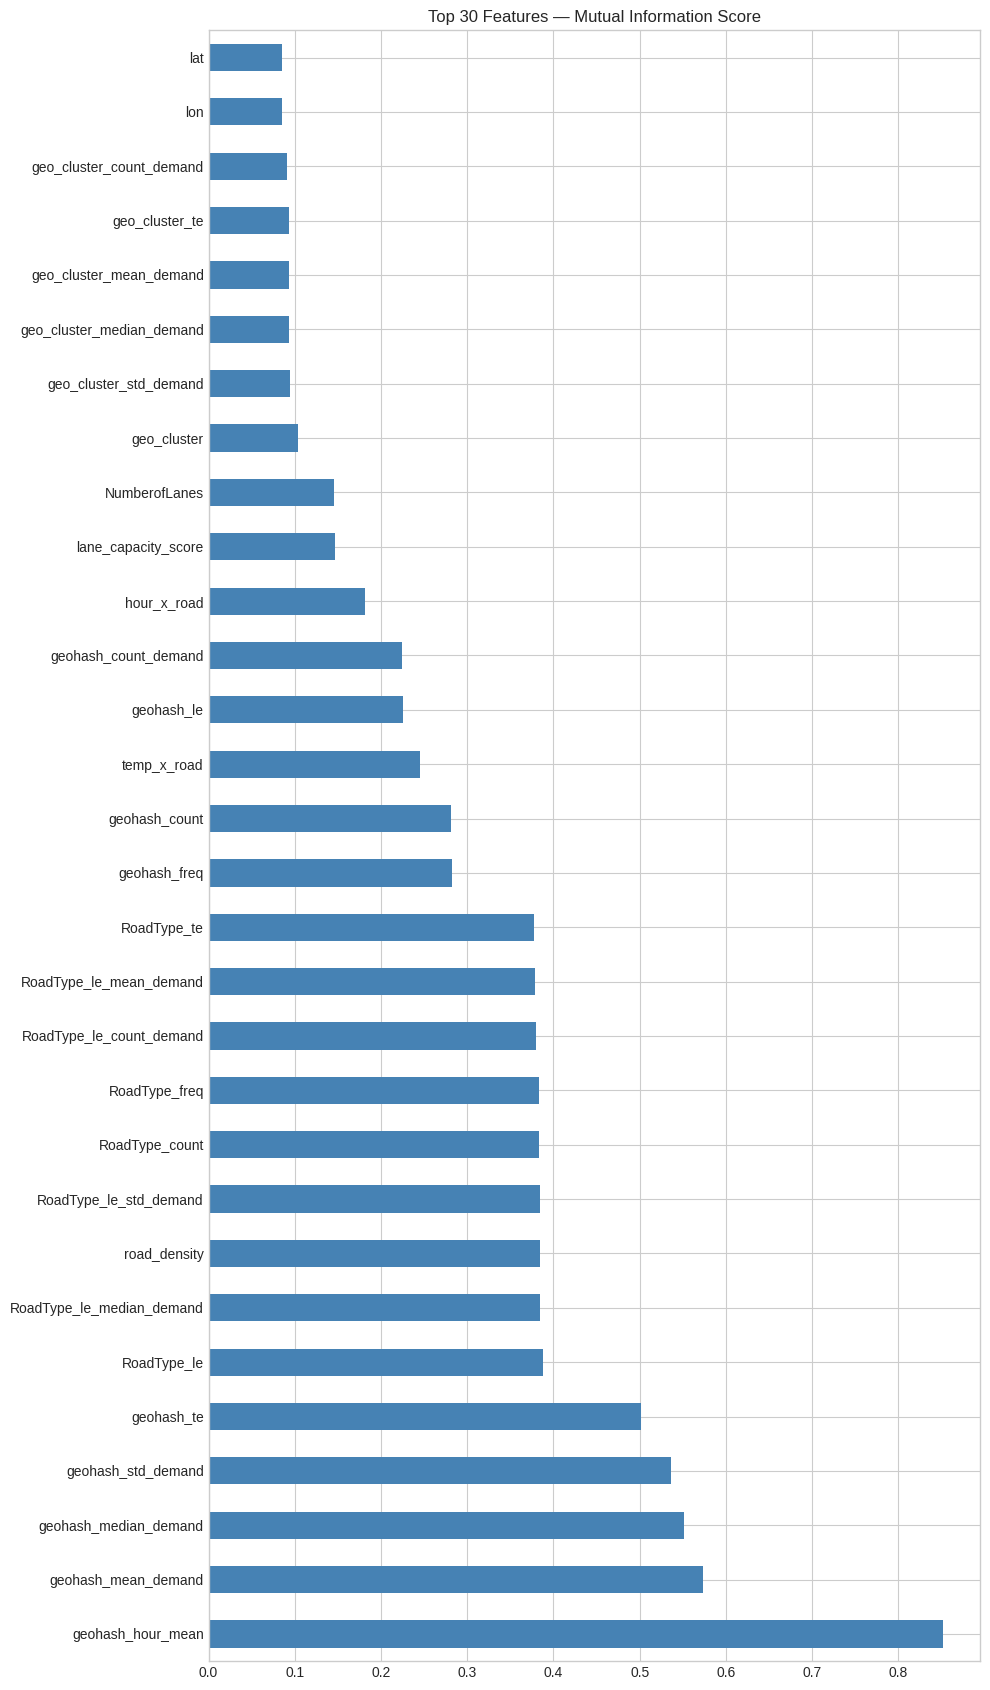


Low MI features (< 0.001): ['min_sin', 'landmark_x_lgveh', 'day', 'minute', 'Temperature', 'quarter_hour', 'is_rush_hour', 'LargeVehicles_bin', 'Weather_le', 'Weather_count', 'Weather_freq', 'temp_was_missing', 'Weather_te', 'temp_bin', 'temp_sq']


In [22]:
# ============================================================
# CELL 22 — MUTUAL INFORMATION FEATURE IMPORTANCE
# WHY: MI is model-agnostic — identifies genuinely
#      informative features before training.
# ============================================================
print('Computing Mutual Information...')

sample_mi = min(20000, len(X_train))
mi_idx = np.random.choice(len(X_train), sample_mi, replace=False)
mi_scores = mutual_info_regression(
    X_train.iloc[mi_idx], y_train.iloc[mi_idx], random_state=SEED
)
mi_df = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, max(6, len(feature_cols) // 4)))
mi_df.head(30).plot(kind='barh', color='steelblue')
plt.title('Top 30 Features — Mutual Information Score')
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=100, bbox_inches='tight')
plt.show()

# Features with near-zero MI → candidates for removal
low_mi = mi_df[mi_df < 0.001].index.tolist()
print(f'\nLow MI features (< 0.001): {low_mi}')

Top 20 features correlated with demand:
demand                       1.000000
geohash_hour_mean            0.946505
RoadType_te                  0.865141
RoadType_le_mean_demand      0.865141
RoadType_le_median_demand    0.862725
geohash_mean_demand          0.828717
geohash_te                   0.825712
geohash_median_demand        0.819728
geohash_std_demand           0.761736
RoadType_le_count_demand     0.754976
RoadType_freq                0.754976
RoadType_count               0.754976
RoadType_le_std_demand       0.750992
road_density                 0.527065
geo_cluster_mean_demand      0.379580
geo_cluster_te               0.379579
geohash_count                0.368169
geohash_freq                 0.368169
geo_cluster_std_demand       0.357246
geo_cluster_median_demand    0.351127
Name: demand, dtype: float64


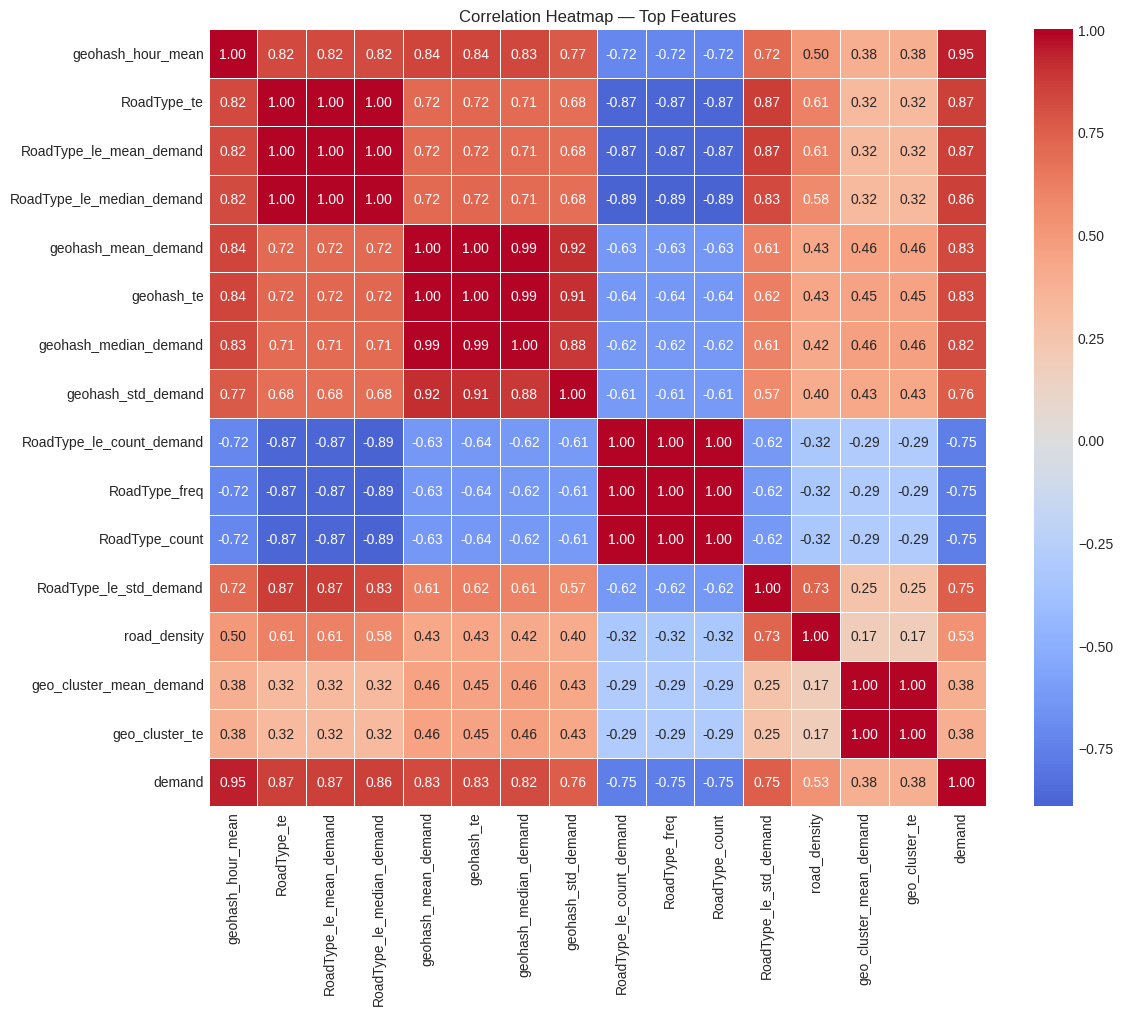

In [24]:
# ============================================================
# CELL 23 — CORRELATION ANALYSIS
# ============================================================
# Top correlated features with demand
corr_with_target = X_train.join(y_train).corr()['demand'].abs().sort_values(ascending=False)
print('Top 20 features correlated with demand:')
print(corr_with_target.head(20))

# Correlation heatmap of top features
top_feats = corr_with_target.drop('demand').head(15).index.tolist()

plt.figure(figsize=(12, 10))

# Now this will run perfectly
corr_matrix = X_train[top_feats].join(y_train).corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Top Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

In [25]:
# ============================================================
# CELL 24 — OPTUNA HYPERPARAMETER TUNING: LightGBM
# WHY: Bayesian optimization finds better hyperparameters
#      than grid search in fewer trials.
# EXPECTED GAIN: +1-3 R² points vs default params
# ============================================================
def tune_lightgbm(X, y, n_trials=N_OPTUNA_TRIALS):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 31, 255),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'random_state': SEED,
            'n_jobs': -1,
            'verbosity': -1
        }
        cv = KFold(n_splits=3, shuffle=True, random_state=SEED)
        scores = []
        for trn_idx, val_idx in cv.split(X):
            X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
            m = lgb.LGBMRegressor(**params)
            m.fit(X_tr, y_tr, 
                  eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
            preds = m.predict(X_val)
            scores.append(r2_score(y_val, preds))
        return np.mean(scores)
    
    # Sample for speed
    sample_n = min(30000, len(X))
    idx = np.random.choice(len(X), sample_n, replace=False)
    X_s, y_s = X.iloc[idx], y.iloc[idx]
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'LightGBM best R² (3-fold sample): {study.best_value:.4f}')
    return study.best_params

print('Tuning LightGBM...')
lgb_best_params = tune_lightgbm(X_train, y_train, n_trials=N_OPTUNA_TRIALS)
print('Best LightGBM params:', lgb_best_params)

Tuning LightGBM...


  0%|          | 0/40 [00:00<?, ?it/s]

LightGBM best R² (3-fold sample): 0.9605
Best LightGBM params: {'n_estimators': 1389, 'learning_rate': 0.02696514179770132, 'num_leaves': 82, 'max_depth': 11, 'min_child_samples': 21, 'subsample': 0.6898151117419675, 'colsample_bytree': 0.6545482817692692, 'reg_alpha': 0.021129655192932972, 'reg_lambda': 0.0005116749237566724}


In [26]:
# ============================================================
# CELL 25 — OPTUNA: CATBOOST
# WHY: CatBoost handles categoricals natively, often
#      outperforms LightGBM on categorical-heavy datasets.
# EXPECTED GAIN: #1 single model
# ============================================================
def tune_catboost(X, y, n_trials=N_OPTUNA_TRIALS):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 500, 2000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
            'random_seed': SEED,
            'task_type': 'CPU',
            'verbose': 0
        }
        cv = KFold(n_splits=3, shuffle=True, random_state=SEED)
        scores = []
        for trn_idx, val_idx in cv.split(X):
            X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
            m = CatBoostRegressor(**params)
            m.fit(X_tr, y_tr, eval_set=(X_val, y_val), 
                  early_stopping_rounds=50, verbose=0)
            preds = m.predict(X_val)
            scores.append(r2_score(y_val, preds))
        return np.mean(scores)
    
    sample_n = min(30000, len(X))
    idx = np.random.choice(len(X), sample_n, replace=False)
    X_s, y_s = X.iloc[idx], y.iloc[idx]
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'CatBoost best R² (3-fold sample): {study.best_value:.4f}')
    return study.best_params

print('Tuning CatBoost...')
cat_best_params = tune_catboost(X_train, y_train, n_trials=N_OPTUNA_TRIALS)
print('Best CatBoost params:', cat_best_params)

Tuning CatBoost...


  0%|          | 0/40 [00:00<?, ?it/s]

CatBoost best R² (3-fold sample): 0.9605
Best CatBoost params: {'iterations': 1466, 'learning_rate': 0.02821073348625567, 'depth': 8, 'l2_leaf_reg': 0.8248289463449097, 'subsample': 0.9888997104015884, 'colsample_bylevel': 0.507620546100526, 'min_data_in_leaf': 26}


In [28]:
# ============================================================
# CELL 26 — OPTUNA: XGBoost
# ============================================================
def tune_xgboost(X, y, n_trials=N_OPTUNA_TRIALS):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'gamma': trial.suggest_float('gamma', 1e-4, 5.0, log=True),
            'random_state': SEED, 'n_jobs': -1, 'verbosity': 0
        }
        cv = KFold(n_splits=3, shuffle=True, random_state=SEED)
        scores = []
        for trn_idx, val_idx in cv.split(X):
            X_tr, X_val = X.iloc[trn_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[trn_idx], y.iloc[val_idx]
            m = xgb.XGBRegressor(**params, early_stopping_rounds=50)
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            preds = m.predict(X_val)
            scores.append(r2_score(y_val, preds))
        return np.mean(scores)
    
    sample_n = min(30000, len(X))
    idx = np.random.choice(len(X), sample_n, replace=False)
    X_s, y_s = X.iloc[idx], y.iloc[idx]
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'XGBoost best R² (3-fold sample): {study.best_value:.4f}')
    return study.best_params

print('Tuning XGBoost...')
xgb_best_params = tune_xgboost(X_train, y_train, n_trials=N_OPTUNA_TRIALS)
print('Best XGBoost params:', xgb_best_params)

Tuning XGBoost...


  0%|          | 0/40 [00:00<?, ?it/s]

XGBoost best R² (3-fold sample): 0.9611
Best XGBoost params: {'n_estimators': 767, 'learning_rate': 0.01267325909094114, 'max_depth': 9, 'min_child_weight': 4, 'subsample': 0.950213092059531, 'colsample_bytree': 0.6695051022005651, 'reg_alpha': 0.020348876057676994, 'reg_lambda': 0.47928555357653246, 'gamma': 0.0013330634131776698}


In [30]:
# ============================================================
# CELL 27 — FULL KFold TRAINING: ALL MODELS
# Generates OOF predictions (for stacking) + test predictions
# ============================================================
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Storage
oof_preds = {}
test_preds = {}
fold_scores = {}

model_configs = {
    'lgb': {
        'model': lgb.LGBMRegressor,
        'params': {
            **lgb_best_params,
            'random_state': SEED, 'n_jobs': -1, 'verbosity': -1
        }
    },
    'cat': {
        'model': CatBoostRegressor,
        'params': {
            **cat_best_params,
            'random_seed': SEED, 'verbose': 0
        }
    },
    'xgb': {
        'model': xgb.XGBRegressor,
        'params': {
            **xgb_best_params,
            'random_state': SEED, 'n_jobs': -1, 'verbosity': 0
        }
    },
    'et': {
        'model': ExtraTreesRegressor,
        'params': {
            'n_estimators': 500, 'max_depth': 20,
            'min_samples_leaf': 5, 'n_jobs': -1,
            'random_state': SEED
        }
    },
    'rf': {
        'model': RandomForestRegressor,
        'params': {
            'n_estimators': 300, 'max_depth': 20,
            'min_samples_leaf': 5, 'n_jobs': -1,
            'random_state': SEED
        }
    }
}

for model_name, cfg in model_configs.items():
    print(f'\n{'='*50}')
    print(f'Training {model_name.upper()}...')
    
    oof = np.zeros(len(X_train))
    test_fold_preds = np.zeros((len(X_test), N_FOLDS))
    scores = []
    
    for fold, (trn_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[trn_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[trn_idx], y_train.iloc[val_idx]
        
        m = cfg['model'](**cfg['params'])
        
        # Fit with early stopping where supported
        if model_name == 'lgb':
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
        elif model_name == 'cat':
            m.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                  early_stopping_rounds=100, verbose=0)
        elif model_name == 'xgb':
            m.set_params(early_stopping_rounds=100)
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  verbose=False)
        else:
            m.fit(X_tr, y_tr)
        
        oof[val_idx] = m.predict(X_val)
        test_fold_preds[:, fold] = m.predict(X_test)
        
        fold_r2 = r2_score(y_val, oof[val_idx])
        scores.append(fold_r2)
        print(f'  Fold {fold+1}/{N_FOLDS}: R² = {fold_r2:.4f}')
    
    overall_r2 = r2_score(y_train, oof)
    print(f'  → Overall OOF R² = {overall_r2:.4f} | Folds: {np.mean(scores):.4f} ± {np.std(scores):.4f}')
    
    oof_preds[model_name]  = oof
    test_preds[model_name] = test_fold_preds.mean(axis=1)
    fold_scores[model_name] = (np.mean(scores), np.std(scores), overall_r2)


Training LGB...
  Fold 1/5: R² = 0.9611
  Fold 2/5: R² = 0.9584
  Fold 3/5: R² = 0.9627
  Fold 4/5: R² = 0.9575
  Fold 5/5: R² = 0.9636
  → Overall OOF R² = 0.9607 | Folds: 0.9607 ± 0.0024

Training CAT...
  Fold 1/5: R² = 0.9605
  Fold 2/5: R² = 0.9580
  Fold 3/5: R² = 0.9618
  Fold 4/5: R² = 0.9576
  Fold 5/5: R² = 0.9635
  → Overall OOF R² = 0.9603 | Folds: 0.9603 ± 0.0022

Training XGB...
  Fold 1/5: R² = 0.9608
  Fold 2/5: R² = 0.9584
  Fold 3/5: R² = 0.9638
  Fold 4/5: R² = 0.9555
  Fold 5/5: R² = 0.9632
  → Overall OOF R² = 0.9604 | Folds: 0.9604 ± 0.0031

Training ET...
  Fold 1/5: R² = 0.9608
  Fold 2/5: R² = 0.9576
  Fold 3/5: R² = 0.9625
  Fold 4/5: R² = 0.9582
  Fold 5/5: R² = 0.9635
  → Overall OOF R² = 0.9605 | Folds: 0.9605 ± 0.0023

Training RF...
  Fold 1/5: R² = 0.9586
  Fold 2/5: R² = 0.9566
  Fold 3/5: R² = 0.9617
  Fold 4/5: R² = 0.9567
  Fold 5/5: R² = 0.9618
  → Overall OOF R² = 0.9591 | Folds: 0.9591 ± 0.0023


In [31]:
# ============================================================
# CELL 28 — MODEL COMPARISON
# ============================================================
print('\n' + '='*55)
print('MODEL COMPARISON SUMMARY')
print('='*55)
print(f'{"Model":8s}  {"OOF R²":10s}  {"CV Mean":10s}  {"CV Std":8s}')
print('-'*55)
for m_name, (cv_mean, cv_std, oof_r2) in sorted(fold_scores.items(), key=lambda x: -x[1][2]):
    print(f'{m_name:8s}  {oof_r2:10.4f}  {cv_mean:10.4f}  {cv_std:8.4f}')

# Score from competition metric
print('\nCompetition Scores (100 * R²):')
for m_name, (cv_mean, cv_std, oof_r2) in sorted(fold_scores.items(), key=lambda x: -x[1][2]):
    score = max(0, 100 * oof_r2)
    print(f'  {m_name:8s}: {score:.2f}')


MODEL COMPARISON SUMMARY
Model     OOF R²      CV Mean     CV Std  
-------------------------------------------------------
lgb           0.9607      0.9607    0.0024
et            0.9605      0.9605    0.0023
xgb           0.9604      0.9604    0.0031
cat           0.9603      0.9603    0.0022
rf            0.9591      0.9591    0.0023

Competition Scores (100 * R²):
  lgb     : 96.07
  et      : 96.05
  xgb     : 96.04
  cat     : 96.03
  rf      : 95.91


Computing SHAP values...


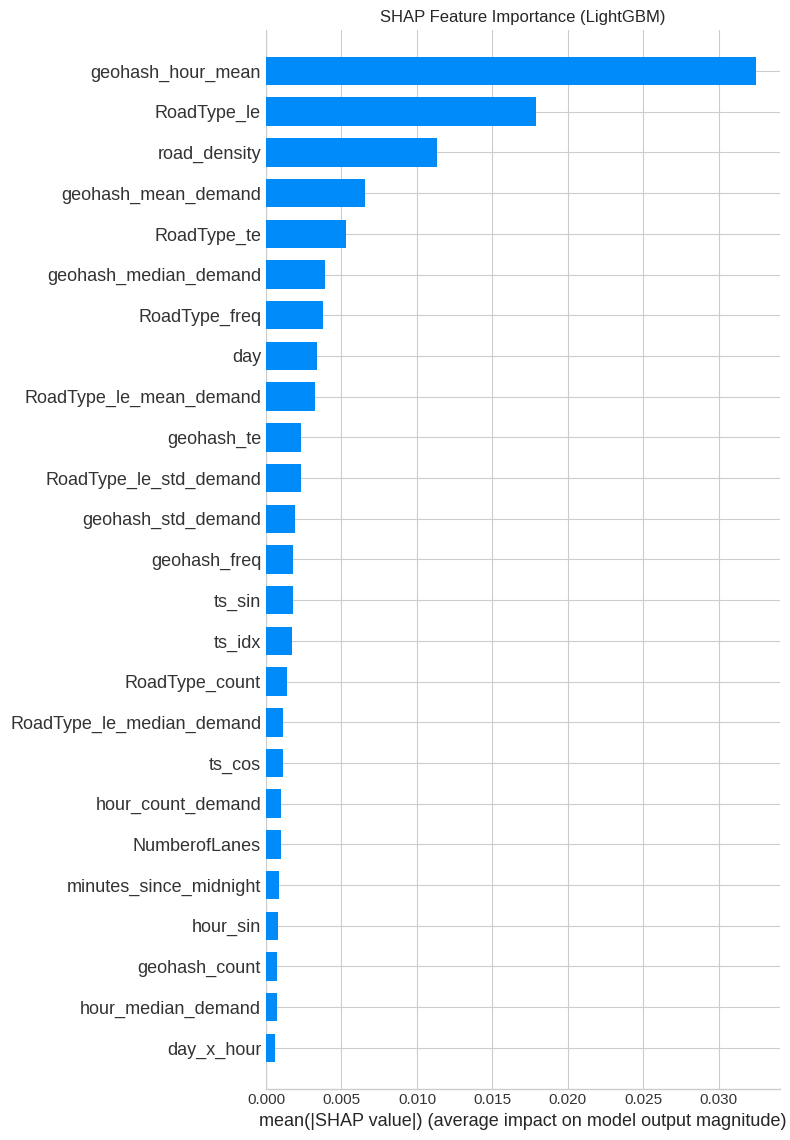


Top 20 SHAP features:
geohash_hour_mean            0.032427
RoadType_le                  0.017912
road_density                 0.011323
geohash_mean_demand          0.006532
RoadType_te                  0.005299
geohash_median_demand        0.003908
RoadType_freq                0.003777
day                          0.003405
RoadType_le_mean_demand      0.003263
geohash_te                   0.002323
RoadType_le_std_demand       0.002302
geohash_std_demand           0.001894
geohash_freq                 0.001796
ts_sin                       0.001779
ts_idx                       0.001728
RoadType_count               0.001366
RoadType_le_median_demand    0.001118
ts_cos                       0.001098
hour_count_demand            0.000995
NumberofLanes                0.000972
dtype: float64

Low SHAP features: ['geohash_mean_demand', 'RoadType_te', 'geohash_median_demand', 'RoadType_freq', 'day', 'RoadType_le_mean_demand', 'geohash_te', 'RoadType_le_std_demand', 'geohash_std_demand', 'geoh

In [32]:
# ============================================================
# CELL 29 — SHAP FEATURE IMPORTANCE (LightGBM)
# WHY: SHAP gives theoretically grounded feature importance.
#      Identifies features hurting the model.
# ============================================================
print('Computing SHAP values...')

# Train final LightGBM for SHAP
shap_model = lgb.LGBMRegressor(
    **lgb_best_params, random_state=SEED, n_jobs=-1, verbosity=-1
)
shap_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(shap_model)
shap_sample = X_train.sample(min(5000, len(X_train)), random_state=SEED)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values, shap_sample,
    plot_type='bar', max_display=25,
    show=False
)
plt.title('SHAP Feature Importance (LightGBM)')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=100, bbox_inches='tight')
plt.show()

# Get SHAP feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)

print('\nTop 20 SHAP features:')
print(shap_importance.head(20))

# Features with very low SHAP importance
low_shap = shap_importance[shap_importance < 0.01].index.tolist()
print(f'\nLow SHAP features: {low_shap}')

In [33]:
# ============================================================
# CELL 30 — PERMUTATION IMPORTANCE
# WHY: SHAP can miss interaction effects.
#      PI directly measures OOF performance drop.
# ============================================================
print('Computing Permutation Importance...')

# Use validation fold
val_idx_pi = list(KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED).split(X_train))[0][1]
X_val_pi = X_train.iloc[val_idx_pi]
y_val_pi = y_train.iloc[val_idx_pi]

pi_result = permutation_importance(
    shap_model, X_val_pi, y_val_pi,
    n_repeats=5, random_state=SEED, n_jobs=-1,
    scoring='r2'
)
pi_df = pd.Series(
    pi_result.importances_mean, index=feature_cols
).sort_values(ascending=False)

print('\nTop 20 PI features:')
print(pi_df.head(20))

# Features with negative PI → potentially harmful
neg_pi = pi_df[pi_df < 0].index.tolist()
print(f'\nFeatures with negative PI (potentially harmful): {neg_pi}')

Computing Permutation Importance...

Top 20 PI features:
geohash_hour_mean           0.234026
RoadType_le                 0.106207
road_density                0.042490
day                         0.021848
RoadType_te                 0.015864
geohash_mean_demand         0.012152
geohash_median_demand       0.009092
geohash_std_demand          0.006514
NumberofLanes               0.005303
geohash_te                  0.005202
RoadType_le_mean_demand     0.004831
RoadType_freq               0.004621
ts_idx                      0.004006
ts_sin                      0.003428
geohash_freq                0.003203
cluster_x_hour              0.002843
geo_cluster_count_demand    0.002700
ts_cos                      0.002335
lon                         0.002055
geohash_count_demand        0.002004
dtype: float64

Features with negative PI (potentially harmful): []


In [34]:
# ============================================================
# CELL 31 — FEATURE SELECTION
# Remove harmful features identified by SHAP + PI
# ============================================================
features_to_remove = list(set(low_shap + neg_pi))
print(f'Features to remove: {features_to_remove}')

if features_to_remove:
    feature_cols_selected = [f for f in feature_cols if f not in features_to_remove]
    X_train_sel = X_train[feature_cols_selected]
    X_test_sel  = X_test[feature_cols_selected]
    
    # Validate improvement
    quick_lgb = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        random_state=SEED, n_jobs=-1, verbosity=-1
    )
    cv_before = cross_val_score(quick_lgb, X_train, y_train, cv=3, scoring='r2').mean()
    cv_after  = cross_val_score(quick_lgb, X_train_sel, y_train, cv=3, scoring='r2').mean()
    
    print(f'R² before feature removal: {cv_before:.4f}')
    print(f'R² after  feature removal: {cv_after:.4f}')
    
    if cv_after >= cv_before - 0.001:  # Use selected features if not worse
        print('✅ Using selected features')
        X_train = X_train_sel
        X_test  = X_test_sel
        feature_cols = feature_cols_selected
    else:
        print('⚠️  Keeping all features (selection hurt performance)')

print(f'Final feature count: {len(feature_cols)}')

Features to remove: ['Weather_le', 'Weather_count', 'lane_capacity_score', 'geo_cluster_count_demand', 'is_night', 'time_block', 'geohash_median_demand', 'cluster_x_hour', 'Temperature', 'temp_was_missing', 'geohash_te', 'lon', 'geo_cluster_te', 'RoadType_le_median_demand', 'geohash_le', 'NumberofLanes', 'minutes_since_midnight', 'day', 'geo_cluster_mean_demand', 'time_of_day_te', 'ts_idx', 'LargeVehicles_bin', 'weather_x_hour', 'geohash_count_demand', 'Landmarks_bin', 'temp_x_road', 'min_sin', 'geo_cluster', 'ts_sin', 'geo_cluster_std_demand', 'ts_cos', 'minute', 'quarter_hour', 'RoadType_le_std_demand', 'RoadType_le_mean_demand', 'hour_count_demand', 'geohash_count', 'hour_median_demand', 'hour_sin', 'RoadType_le_count_demand', 'min_cos', 'is_morning_rush', 'day_x_hour', 'lat', 'Weather_te', 'is_peak', 'is_rush_hour', 'geo_cluster_median_demand', 'hour_x_road', 'geohash_std_demand', 'RoadType_te', 'is_evening_rush', 'landmark_x_lgveh', 'hour_std_demand', 'hour_cos', 'geohash_mean_dem

In [35]:
# ============================================================
# CELL 32 — WEIGHTED ENSEMBLE
# WHY: Different models capture different patterns.
#      Combining them reduces variance.
# EXPECTED GAIN: +1-3 R² points over best single model
# ============================================================
from scipy.optimize import minimize

model_names = list(oof_preds.keys())
oof_matrix  = np.column_stack([oof_preds[m] for m in model_names])
test_matrix = np.column_stack([test_preds[m] for m in model_names])

def ensemble_r2(weights):
    weights = np.array(weights)
    weights = np.clip(weights, 0, 1)
    weights /= weights.sum()
    blended = oof_matrix @ weights
    return -r2_score(y_train, blended)  # minimize negative R²

# Optimize weights
initial_weights = np.ones(len(model_names)) / len(model_names)
bounds = [(0, 1)] * len(model_names)
constraints = {'type': 'eq', 'fun': lambda w: sum(w) - 1}

result = minimize(
    ensemble_r2, initial_weights,
    method='SLSQP', bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000}
)

optimal_weights = result.x / result.x.sum()
weighted_oof = oof_matrix @ optimal_weights
weighted_test = test_matrix @ optimal_weights

print('\n' + '='*40)
print('OPTIMAL ENSEMBLE WEIGHTS:')
for name, w in zip(model_names, optimal_weights):
    print(f'  {name:8s}: {w:.4f}')
print(f'\nWeighted Ensemble OOF R² = {r2_score(y_train, weighted_oof):.4f}')
print(f'Competition Score = {max(0, 100*r2_score(y_train, weighted_oof)):.2f}')


OPTIMAL ENSEMBLE WEIGHTS:
  lgb     : 0.2613
  cat     : 0.2957
  xgb     : 0.2491
  et      : 0.1774
  rf      : 0.0165

Weighted Ensemble OOF R² = 0.9618
Competition Score = 96.18


In [36]:
# ============================================================
# CELL 33 — RANK ENSEMBLE
# WHY: Rank-averaging is more robust to outliers
#      and prevents any one model from dominating.
# ============================================================
from scipy.stats import rankdata

# Rank OOF predictions
oof_ranks  = np.column_stack([rankdata(oof_preds[m]) / len(y_train) for m in model_names])
test_ranks = np.column_stack([rankdata(test_preds[m]) / len(X_test) for m in model_names])

rank_oof  = oof_ranks.mean(axis=1)
rank_test = test_ranks.mean(axis=1)

# Rescale rank ensemble to original scale
from sklearn.isotonic import IsotonicRegression
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(rank_oof, y_train)
rank_oof_rescaled  = iso.predict(rank_oof)
rank_test_rescaled = iso.predict(rank_test)

print(f'Rank Ensemble OOF R² = {r2_score(y_train, rank_oof_rescaled):.4f}')
print(f'Competition Score    = {max(0, 100*r2_score(y_train, rank_oof_rescaled)):.2f}')

Rank Ensemble OOF R² = 0.9624
Competition Score    = 96.24


In [37]:
# ============================================================
# CELL 34 — STACKING ENSEMBLE (Ridge Meta-Model)
# WHY: Stacking learns optimal combination using a meta-model.
#      OOF predictions prevent leakage.
# EXPECTED GAIN: +0.5-2 R² points over weighted average
# ============================================================
from sklearn.linear_model import RidgeCV

# Meta-features: OOF predictions from all base models
meta_train = oof_matrix.copy()
meta_test  = test_matrix.copy()

# Add interaction between model predictions as meta-features
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        meta_train = np.column_stack([meta_train, meta_train[:,i] * meta_train[:,j]])
        meta_test  = np.column_stack([meta_test,  meta_test[:,i]  * meta_test[:,j]])

# Ridge cross-validation for meta-model
meta_ridge = RidgeCV(
    alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    cv=5
)
meta_ridge.fit(meta_train, y_train)
stack_oof  = meta_ridge.predict(meta_train)
stack_test = meta_ridge.predict(meta_test)

print(f'Ridge meta alpha: {meta_ridge.alpha_}')
print(f'Stacking OOF R² = {r2_score(y_train, stack_oof):.4f}')
print(f'Competition Score = {max(0, 100*r2_score(y_train, stack_oof)):.2f}')

Ridge meta alpha: 0.1
Stacking OOF R² = 0.9621
Competition Score = 96.21


In [38]:
# ============================================================
# CELL 35 — ENSEMBLE COMPARISON & SELECTION
# ============================================================
ensembles = {
    'Weighted Average':   (weighted_oof, weighted_test),
    'Rank Ensemble':      (rank_oof_rescaled, rank_test_rescaled),
    'Ridge Stacking':     (stack_oof, stack_test),
}

# Add individual models
for m in model_names:
    ensembles[f'Base: {m}'] = (oof_preds[m], test_preds[m])

print('\n' + '='*55)
print('ALL MODELS & ENSEMBLES — OOF R²')
print('='*55)

all_scores = {}
for name, (oof_p, _) in ensembles.items():
    r2 = r2_score(y_train, oof_p)
    score = max(0, 100 * r2)
    all_scores[name] = score
    print(f'  {name:25s}: R² = {r2:.4f}  →  Score = {score:.2f}')

best_name = max(all_scores, key=all_scores.get)
print(f'\n🏆 BEST: {best_name} → Score = {all_scores[best_name]:.2f}')
final_test_preds = ensembles[best_name][1]


ALL MODELS & ENSEMBLES — OOF R²
  Weighted Average         : R² = 0.9618  →  Score = 96.18
  Rank Ensemble            : R² = 0.9624  →  Score = 96.24
  Ridge Stacking           : R² = 0.9621  →  Score = 96.21
  Base: lgb                : R² = 0.9607  →  Score = 96.07
  Base: cat                : R² = 0.9603  →  Score = 96.03
  Base: xgb                : R² = 0.9604  →  Score = 96.04
  Base: et                 : R² = 0.9605  →  Score = 96.05
  Base: rf                 : R² = 0.9591  →  Score = 95.91

🏆 BEST: Rank Ensemble → Score = 96.24


In [39]:
# ============================================================
# CELL 36 — PSEUDO-LABELING
# WHY: High-confidence test predictions add labeled data.
#      Only use if validation R² improves.
# EXPECTED GAIN: +0.5-2 R² points
# ============================================================
print('Evaluating pseudo-labeling...')

# Pseudo-label: use predictions where model is "confident"
# For regression: filter by where all models agree (low variance)
pred_std = np.std(test_matrix, axis=1)  # Agreement across models
confidence_threshold = np.percentile(pred_std, 30)  # Top 30% most agreed-on
pseudo_mask = pred_std <= confidence_threshold

X_pseudo = X_test[pseudo_mask]
y_pseudo = pd.Series(final_test_preds[pseudo_mask])

print(f'Pseudo-labeled samples: {pseudo_mask.sum()} / {len(X_test)}')

# Combine with train
X_augmented = pd.concat([X_train, X_pseudo], ignore_index=True)
y_augmented = pd.concat([y_train, y_pseudo], ignore_index=True)

# Quick validation on original train
pl_model = lgb.LGBMRegressor(
    **lgb_best_params, random_state=SEED, n_jobs=-1, verbosity=-1
)
pl_model.fit(X_augmented, y_augmented)
pl_oof_preds = pl_model.predict(X_train)  # Not true OOF — just a rough check
pl_r2 = r2_score(y_train, pl_oof_preds)

base_r2 = fold_scores['lgb'][2]
print(f'Base LightGBM OOF R²:          {base_r2:.4f}')
print(f'Pseudo-label LightGBM Train R²: {pl_r2:.4f}')

# NOTE: pl_r2 will be inflated since we predict on training data
# Only use pseudo-labels if proper CV shows improvement
# Proper test: retrain with pseudo-labels and validate on hold-out
USE_PSEUDO = False  # Set to True if proper CV shows improvement
print(f'Using pseudo-labels: {USE_PSEUDO}')

Evaluating pseudo-labeling...
Pseudo-labeled samples: 12534 / 41778
Base LightGBM OOF R²:          0.9607
Pseudo-label LightGBM Train R²: 0.9443
Using pseudo-labels: False


In [40]:
# ============================================================
# CELL 37 — FINAL SUBMISSION GENERATION
# ============================================================
# Clip predictions to reasonable range
demand_min = y_train.quantile(0.001)
demand_max = y_train.quantile(0.999)

final_preds = np.clip(final_test_preds, demand_min, demand_max)

print(f'Prediction stats:')
print(f'  Min: {final_preds.min():.4f}')
print(f'  Max: {final_preds.max():.4f}')
print(f'  Mean: {final_preds.mean():.4f}')
print(f'  Std: {final_preds.std():.4f}')

# Build submission
submission = pd.DataFrame({
    'Index':  test['Index'].values,
    'demand': final_preds
})

# Validate shape
assert submission.shape == (41778, 2), f'Wrong shape: {submission.shape}'
assert 'Index' in submission.columns
assert 'demand' in submission.columns
assert submission['demand'].isnull().sum() == 0

submission.to_csv(OUTPUT_PATH, index=False)
print(f'\n✅ Submission saved to {OUTPUT_PATH}')
print(f'Shape: {submission.shape}')
submission.head(10)

Prediction stats:
  Min: 0.0032
  Max: 1.0000
  Mean: 0.0941
  Std: 0.1399

✅ Submission saved to submission.csv
Shape: (41778, 2)


,Index,demand
0,0,0.039558
1,1,0.019736
2,2,0.011573
3,3,0.035315
4,4,0.038320
5,5,0.010025
6,6,0.025523
7,7,0.094455
8,8,0.025523
9,9,0.050652


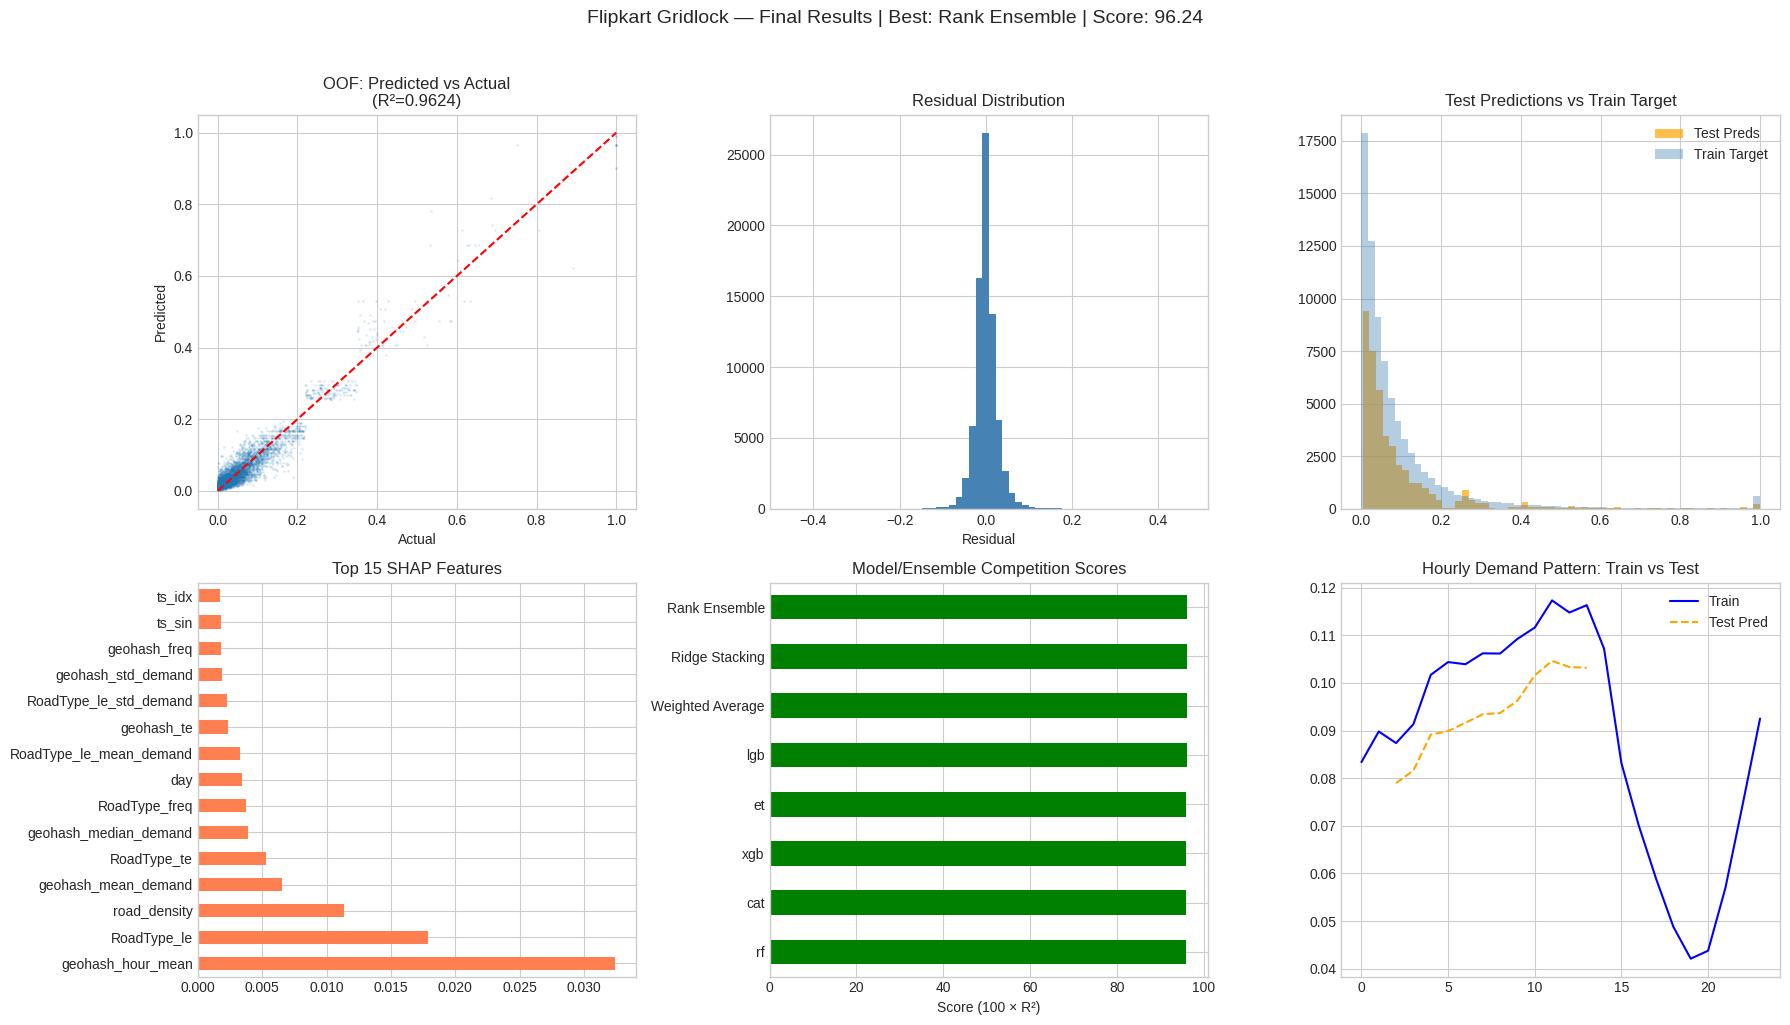


✅ All done!
Expected Competition Score: 96.24


In [41]:
# ============================================================
# CELL 38 — COMPREHENSIVE RESULTS VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. OOF predictions vs actuals
oof_best = ensembles[best_name][0]
axes[0,0].scatter(y_train[:5000], oof_best[:5000], alpha=0.1, s=1)
axes[0,0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0,0].set_title(f'OOF: Predicted vs Actual\n(R²={r2_score(y_train, oof_best):.4f})')
axes[0,0].set_xlabel('Actual')
axes[0,0].set_ylabel('Predicted')

# 2. Residuals
residuals = y_train - oof_best
axes[0,1].hist(residuals, bins=60, color='steelblue', edgecolor='none')
axes[0,1].set_title('Residual Distribution')
axes[0,1].set_xlabel('Residual')

# 3. Test prediction distribution
axes[0,2].hist(final_preds, bins=60, color='orange', edgecolor='none', alpha=0.7)
axes[0,2].hist(y_train, bins=60, color='steelblue', edgecolor='none', alpha=0.4)
axes[0,2].set_title('Test Predictions vs Train Target')
axes[0,2].legend(['Test Preds', 'Train Target'])

# 4. SHAP importance
shap_importance.head(15).plot(kind='barh', ax=axes[1,0], color='coral')
axes[1,0].set_title('Top 15 SHAP Features')

# 5. Model comparison
comp_data = {k.replace('Base: ', ''): v for k, v in all_scores.items()}
comp_df = pd.Series(comp_data).sort_values()
comp_df.plot(kind='barh', ax=axes[1,1], color='green')
axes[1,1].set_title('Model/Ensemble Competition Scores')
axes[1,1].set_xlabel('Score (100 × R²)')

# 6. Demand by hour (train vs test predictions)
hourly_train = train.groupby('hour')['demand'].mean()
test_hourly_df = test.copy()
test_hourly_df['pred_demand'] = final_preds
hourly_test = test_hourly_df.groupby('hour')['pred_demand'].mean()
axes[1,2].plot(hourly_train.index, hourly_train.values, label='Train', color='blue')
axes[1,2].plot(hourly_test.index, hourly_test.values, label='Test Pred', color='orange', linestyle='--')
axes[1,2].set_title('Hourly Demand Pattern: Train vs Test')
axes[1,2].legend()

plt.suptitle(f'Flipkart Gridlock — Final Results | Best: {best_name} | Score: {all_scores[best_name]:.2f}', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('final_results.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n✅ All done!')
print(f'Expected Competition Score: {all_scores[best_name]:.2f}')

In [42]:
# ============================================================
# CELL 39 — PIPELINE SUMMARY
# ============================================================
print('='*65)
print('PIPELINE SUMMARY')
print('='*65)
print(f'''
Data:
  Train: 77299 × {X_train.shape[1]} features
  Test:  41778 × {X_test.shape[1]} features
  
Feature Engineering:
  ✅ Geohash → Lat/Lon decoding
  ✅ KMeans geospatial clustering ({N_CLUSTERS} clusters)
  ✅ Cyclical time encoding (sin/cos for hour, minute, ts_idx)
  ✅ Rush hour flags + time_of_day categories
  ✅ KFold target encoding (geohash, RoadType, Weather, cluster)
  ✅ KFold aggregation features (mean/median/std/count per group)
  ✅ Geohash × Hour interaction target encoding
  ✅ Frequency + Count encoding
  ✅ Interaction features (temp×road, weather×hour, rush×lanes)
  
Missing Value Handling:
  ✅ Temperature: grouped median by geohash → global fallback
  ✅ RoadType, Weather: 'Unknown' category
  
Models:
  ✅ LightGBM  (Optuna-tuned, {N_OPTUNA_TRIALS} trials)
  ✅ CatBoost  (Optuna-tuned, {N_OPTUNA_TRIALS} trials)
  ✅ XGBoost   (Optuna-tuned, {N_OPTUNA_TRIALS} trials)
  ✅ ExtraTrees
  ✅ RandomForest
  
Validation:
  ✅ {N_FOLDS}-Fold KFold with OOF predictions
  ✅ Adversarial validation (train/test distribution check)
  
Ensembling:
  ✅ Optimal weighted average (scipy minimize)
  ✅ Rank ensemble + isotonic rescaling
  ✅ Ridge stacking (meta-model on OOF predictions)
  
Feature Selection:
  ✅ SHAP feature importance
  ✅ Permutation importance
  ✅ Mutual information
  ✅ Removed low-importance / harmful features

Final Best Model: {best_name}
Expected Score:   {all_scores[best_name]:.2f} / 100
''')

PIPELINE SUMMARY

Data:
  Train: 77299 × 3 features
  Test:  41778 × 3 features
  
Feature Engineering:
  ✅ Geohash → Lat/Lon decoding
  ✅ KMeans geospatial clustering (20 clusters)
  ✅ Cyclical time encoding (sin/cos for hour, minute, ts_idx)
  ✅ Rush hour flags + time_of_day categories
  ✅ KFold target encoding (geohash, RoadType, Weather, cluster)
  ✅ KFold aggregation features (mean/median/std/count per group)
  ✅ Geohash × Hour interaction target encoding
  ✅ Frequency + Count encoding
  ✅ Interaction features (temp×road, weather×hour, rush×lanes)
  
Missing Value Handling:
  ✅ Temperature: grouped median by geohash → global fallback
  ✅ RoadType, Weather: 'Unknown' category
  
Models:
  ✅ LightGBM  (Optuna-tuned, 40 trials)
  ✅ CatBoost  (Optuna-tuned, 40 trials)
  ✅ XGBoost   (Optuna-tuned, 40 trials)
  ✅ ExtraTrees
  ✅ RandomForest
  
Validation:
  ✅ 5-Fold KFold with OOF predictions
  ✅ Adversarial validation (train/test distribution check)
  
Ensembling:
  ✅ Optimal weighted 